In [ ]:
import tifffile


In [ ]:
import os
import pandas as pd

input_directory = r"E:\ExpEM011_Imaging_20x_2ndtry"
for dir in os.listdir(input_directory):
    if os.path.isdir(os.path.join(input_directory, dir)):
        proprties_folder = os.path.join(input_directory, dir, "properties")
        if os.path.exists(proprties_folder):
            for file in os.listdir(proprties_folder):
                if file.endswith(".csv"):
                    # delte the csv file
                    os.remove(os.path.join(proprties_folder, file))

In [5]:
import tifffile

import os
import re
import json
import numpy as np


def file_to_folder(input_directory):
    import os
    import shutil

    for file in os.listdir(input_directory):
        file_path = os.path.join(input_directory, file)

        if os.path.isfile(file_path) and file.endswith(
            (".tif", ".tiff", ".ims", ".nd")
        ):
            folder_name = os.path.splitext(file)[0]
            new_folder_path = os.path.join(input_directory, folder_name)
            os.makedirs(new_folder_path, exist_ok=True)

            if not file_path.endswith(".nd"):
                shutil.move(file_path, os.path.join(new_folder_path, file))
            else:
                shutil.move(file_path, os.path.join(new_folder_path, file))
                base_name = os.path.splitext(file)[0]
                other_files = [
                    f
                    for f in os.listdir(input_directory)
                    if f.startswith(base_name) and f.lower().endswith(".stk")
                ]
                for other_file in other_files:
                    shutil.move(
                        os.path.join(input_directory, other_file),
                        os.path.join(new_folder_path, other_file),
                    )
                output_tif = nd_to_tif(os.path.join(new_folder_path, file))
                if os.path.exists(output_tif):
                    os.remove(os.path.join(new_folder_path, file))
                    for other_file in other_files:
                        os.remove(
                            os.path.join(new_folder_path, other_file)
                        )

    return


def _natural_key(s):
    return [int(t) if t.isdigit() else t.lower() for t in re.split(r"(\d+)", s)]


def _parse_nd_metadata(nd_path):
    meta = {}
    with open(nd_path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith(";"):
                continue
            m = re.match(r'"?([^",]+)"?\s*,\s*"?(.*?)"?$', line)
            if m:
                key = m.group(1).strip()
                val = m.group(2).strip()
                meta[key] = val
    return meta


def _to_int(value):
    try:
        return int(float(value))
    except Exception:
        return None


def _to_float(value):
    try:
        return float(value)
    except Exception:
        return None


def _get_first_numeric(meta, keys):
    for k in keys:
        if k in meta:
            v = _to_float(meta[k])
            if v is not None:
                return v
    return None


def nd_to_tif(input_file):
    """Convert MetaMorph ND + STK series to TIFF with OME metadata, axes T,Z,C,Y,X."""
    nd_meta = _parse_nd_metadata(input_file)
    input_dir = os.path.dirname(input_file)
    base_name = os.path.splitext(os.path.basename(input_file))[0]

    stk_files = sorted(
        [
            f
            for f in os.listdir(input_dir)
            if f.startswith(base_name) and f.lower().endswith(".stk")
        ],
        key=_natural_key,
    )
    if not stk_files:
        raise FileNotFoundError(f"No STK files found for {input_file}")

    records = []  # (t_idx, c_idx, stack, filename)
    for f in stk_files:
        full = os.path.join(input_dir, f)
        stack = tifffile.imread(full)
        if stack.ndim == 2:
            stack = stack[np.newaxis, :, :]  # Z, Y, X
        elif stack.ndim != 3:
            raise ValueError(f"Unexpected STK shape {stack.shape} for {f}")

        m_t = re.search(r"(?:^|[_-])t(\d+)", f, flags=re.IGNORECASE)
        m_w = re.search(r"(?:^|[_-])w(\d+)", f, flags=re.IGNORECASE)
        t_token = int(m_t.group(1)) if m_t else None
        c_token = int(m_w.group(1)) if m_w else None
        records.append((t_token, c_token, stack, f))

    first_shape = records[0][2].shape
    for _, _, st, fn in records[1:]:
        if st.shape != first_shape:
            raise ValueError(
                f"STK stacks are not the same shape: {records[0][3]} {first_shape} vs {fn} {st.shape}"
            )

    z, y, x = first_shape
    token_ts = [r[0] for r in records if r[0] is not None]
    token_cs = [r[1] for r in records if r[1] is not None]

    n_t_meta = _to_int(nd_meta.get("NTimePoints") or nd_meta.get("NumberOfTimePoints"))
    n_c_meta = _to_int(nd_meta.get("NWavelengths") or nd_meta.get("NumberOfWavelengths"))

    n_t = max(token_ts) if token_ts else (n_t_meta if n_t_meta else None)
    n_c = max(token_cs) if token_cs else (n_c_meta if n_c_meta else None)

    if n_t is None and n_c is None:
        n_t, n_c = len(records), 1
    elif n_t is None:
        n_t = int(np.ceil(len(records) / n_c))
    elif n_c is None:
        n_c = int(np.ceil(len(records) / n_t))

    one_based_t = len(token_ts) > 0 and min(token_ts) >= 1
    one_based_c = len(token_cs) > 0 and min(token_cs) >= 1

    # Final output order: T, Z, C, Y, X
    data = np.zeros((n_t, z, n_c, y, x), dtype=records[0][2].dtype)

    for i, (t_token, c_token, stack, _) in enumerate(records):
        if t_token is None:
            t_idx = i // n_c
        else:
            t_idx = (t_token - 1) if one_based_t else t_token

        if c_token is None:
            c_idx = i % n_c
        else:
            c_idx = (c_token - 1) if one_based_c else c_token

        if t_idx >= n_t or c_idx >= n_c or t_idx < 0 or c_idx < 0:
            raise IndexError(
                f"Computed index out of bounds for record {i}: t={t_idx}, c={c_idx}, shape={(n_t, z, n_c, y, x)}"
            )
        data[t_idx, :, c_idx, :, :] = stack

    metadata = {"axes": "TZCYX"}

    ch_names = []
    for idx in range(1, n_c + 1):
        key = f"WaveName{idx}"
        if key in nd_meta and nd_meta[key]:
            ch_names.append(nd_meta[key])
    if len(ch_names) == n_c:
        metadata["Channel"] = {"Name": ch_names}

    px = _get_first_numeric(nd_meta, ["PixelSizeX", "XCalibrationMicrons", "XCalibration", "dXCalibration"])
    py = _get_first_numeric(nd_meta, ["PixelSizeY", "YCalibrationMicrons", "YCalibration", "dYCalibration"])
    pz = _get_first_numeric(nd_meta, ["ZStep", "ZStepSize", "StepSize", "dZStep"])
    dt = _get_first_numeric(nd_meta, ["TimeIncrement", "SamplingInterval", "Interval", "dTimeStep"])

    if px and px > 0:
        metadata["PhysicalSizeX"] = px
        metadata["PhysicalSizeXUnit"] = "um"
    if py and py > 0:
        metadata["PhysicalSizeY"] = py
        metadata["PhysicalSizeYUnit"] = "um"
    if pz and pz > 0:
        metadata["PhysicalSizeZ"] = pz
        metadata["PhysicalSizeZUnit"] = "um"
    if dt and dt > 0:
        metadata["TimeIncrement"] = dt
        metadata["TimeIncrementUnit"] = "s"

    output_file = os.path.splitext(input_file)[0] + ".tif"
    tifffile.imwrite(
        output_file,
        data,
        ome=True,
        metadata=metadata,
        bigtiff=True,
        compression="zlib",
        compressionargs={"level": 1},
    )

    sidecar = os.path.splitext(output_file)[0] + "_nd_metadata.json"
    with open(sidecar, "w", encoding="utf-8") as f:
        json.dump(nd_meta, f, indent=2, ensure_ascii=False)

    return output_file


input_directory = r"C:\Users\6331823\Local SSD\Data_Mo\ND files"

file_to_folder(input_directory)

In [ ]:
input_directory = r"C:\Users\6331823\Local SSD\Data_Mo\ND files"
output_directory = r"C:\Users\6331823\Local SSD\Data_Mo\Train model mo"

for dir in os.listdir(input_directory):
    if os.path.isdir(os.path.join(input_directory, dir)):
        image = os.path.join(input_directory, dir, dir + ".tif")
        image = tifffile.imread(image)
        nuclei = image[0]
        random_index = np.random.randint(0, nuclei.shape[0], size=10)
        for i, idx in enumerate(random_index):
            tifffile.imwrite(
                os.path.join(output_directory, f"{dir}_nuclei_{i}.tif"),
                nuclei[idx],
            )

In [11]:
import numpy as np
from pathlib import Path

src = Path(r"C:\Users\6331823\Local SSD\Data_Mo\Train model mo\extra_3_seg.npy")
dst = src.with_name(src.stem + "_neg_seg.npy")

obj = np.load(src, allow_pickle=True)

# Handle common .npy layouts: pickled dict, object scalar, object array, or [image, mask] array
if isinstance(obj, np.ndarray) and obj.dtype == object and obj.shape == ():
    obj = obj.item()

if isinstance(obj, dict):
    # Most robust: zero any key that looks like a mask
    new_obj = dict(obj)
    mask_keys = [k for k in new_obj.keys() if "mask" in str(k).lower()]
    if not mask_keys:
        raise ValueError(f"No mask-like key found in dict. Keys: {list(new_obj.keys())}")
    for k in mask_keys:
        new_obj[k] = np.zeros_like(new_obj[k])
    np.save(dst, new_obj, allow_pickle=True)

elif isinstance(obj, np.ndarray) and obj.dtype == object and obj.size >= 2:
    seq = list(obj)
    seq[1] = np.zeros_like(seq[1])
    np.save(dst, np.array(seq, dtype=object), allow_pickle=True)

elif isinstance(obj, (list, tuple)) and len(obj) >= 2:
    seq = list(obj)
    seq[1] = np.zeros_like(seq[1])
    np.save(dst, np.array(seq, dtype=object), allow_pickle=True)

else:
    raise ValueError(f"Unsupported structure: type={type(obj)}, dtype={getattr(obj, 'dtype', None)}, shape={getattr(obj, 'shape', None)}")

print(f"Saved: {dst}")
print(f"Exists: {dst.exists()}")

Saved: C:\Users\6331823\Local SSD\Data_Mo\Train model mo\extra_3_seg_neg_seg.npy
Exists: True


In [ ]:
import napari
import tifffile
import os
import cv2 as cv
import numpy as np

input_directory = r"C:\Users\6331823\Local SSD\Data_Mo\ND files\20251216_gapstrain_1_1"
segmentation_cleaned = tifffile.imread(
    os.path.join(input_directory, f"segmentation_cleaned.tif")
)
segmentation_old = tifffile.imread(
    os.path.join(input_directory, f"{os.path.basename(input_directory)}_segmented old.tif")
)
segmentation_new = tifffile.imread(
    os.path.join(input_directory, f"{os.path.basename(input_directory)}_segmented.tif")
)
image = tifffile.imread(
    os.path.join(input_directory, f"20251216_gapstrain_1_1_cropped.tif")
)[:,0]

corrected_image = np.zeros_like(image)
denoised_image = np.zeros_like(image)
for z in range(image.shape[0]):
    img = image[z]

    # Normalize to 8-bit for processing
    img_normalized = cv.normalize(img, None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)

    # Convert to 3 channels if needed (fastNlMeansDenoisingColored requires 3 or 4 channels)
    if len(img_normalized.shape) == 2:
        img_normalized = cv.cvtColor(img_normalized, cv.COLOR_GRAY2BGR)
    elif img_normalized.shape[2] == 1:
        img_normalized = cv.cvtColor(img_normalized, cv.COLOR_GRAY2BGR)

    # Now denoise
    dst = cv.fastNlMeansDenoisingColored(img_normalized, None, 10, 10, 7, 21)

    print(np.median(img_normalized), np.median(dst))
    subtracted = cv.subtract(dst, np.median(dst))
    corrected_image[z] = subtracted[:,:,0]  # Take one channel back to 2D
    denoised_image[z] = dst[:,:,0]  # Store the denoised image as well
another_image = cv.subtract(denoised_image, np.median(denoised_image))

stack_normalized = cv.normalize(image, None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)
stack_denoised = cv.fastNlMeansDenoisingMulti(stack_normalized, None, 10, 7, 21)

scale = (0.25, 0.057, 0.057)  # Example scale values for Z, Y, X in microns
viewer = napari.Viewer(ndisplay=3)
viewer.add_labels(segmentation_cleaned, name="segmentation_cleaned", scale = scale)
viewer.add_labels(segmentation_old, name="segmentation_old", scale = scale)
viewer.add_labels(segmentation_new, name="segmentation_new", scale = scale)
viewer.add_image(image, name="image", scale = scale)
viewer.add_image(corrected_image, name="corrected_image", scale = scale)
viewer.add_image(denoised_image, name="denoised_image", scale = scale)
viewer.add_image(another_image, name="another_image", scale = scale)


111.0 113.0
107.0 109.0
98.0 100.0
107.0 109.0
109.0 111.0
107.0 110.0
104.0 106.0
106.0 107.0
104.0 106.0
95.0 96.0
96.0 97.0
86.0 88.0
88.0 89.0
75.0 76.0
80.0 82.0
85.0 85.0
84.0 84.0
91.0 92.0
94.0 96.0
92.0 93.0
91.0 92.0
86.0 87.0
84.0 84.0
88.0 89.0
90.0 90.0
81.0 82.0
77.0 77.0
65.0 66.0
78.0 78.0
73.0 73.0
73.0 75.0
77.0 78.0
82.0 83.0
73.0 73.0
89.0 91.0
89.0 90.0
86.0 88.0
89.0 90.0
82.0 83.0
80.0 80.0
80.0 80.0
81.0 82.0
83.0 84.0
74.0 75.0
79.0 80.0
86.0 88.0
84.0 85.0
86.0 88.0
90.0 92.0
90.0 92.0
85.0 88.0
74.0 76.0
85.0 87.0
90.0 92.0
80.0 80.0
86.0 87.0
79.0 80.0
74.0 75.0
72.0 72.0
90.0 90.0
67.0 68.0


<Image layer 'another_image' at 0x1b80e871cf0>

In [7]:
stack_normalized = cv.normalize(image, None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)
N = stack_normalized.shape[0]
temporal_window = 3
half = temporal_window // 2

if N < temporal_window:
    raise ValueError(f"Need at least {temporal_window} slices, got {N}")

# list of 2D uint8 slices
stack_normalized_list = [stack_normalized[i].astype(np.uint8) for i in range(N)]

stack_denoised = np.empty_like(stack_normalized, dtype=np.uint8)

for z in range(N):
    print(f"Processing slice {z+1}/{N}")

    if z < half or z >= N - half:
        # edge handling: copy original (or use single-image denoising here)
        stack_denoised[z] = stack_normalized_list[z]
    else:
        stack_denoised[z] = cv.fastNlMeansDenoisingMulti(
            stack_normalized_list,  # list of slices
            z,  # center index in full list
            temporal_window,  # must be odd
            None,
            10,
            7,
            21,
        )

stack_denoised_subtracted = cv.subtract(stack_denoised, np.median(stack_denoised))
#skipfirst and last z

scale = (0.25, 0.057, 0.057)  # Example scale values for Z, Y, X in microns
viewer = napari.Viewer(ndisplay=3)
viewer.add_labels(segmentation_cleaned, name="segmentation_cleaned", scale=scale, blending='additive', visible=False)
viewer.add_labels(segmentation_old, name="segmentation_old", scale=scale, blending='additive', visible=False)
viewer.add_labels(segmentation_new, name="segmentation_new", scale=scale, blending='additive', visible=False)
viewer.add_image(image, name="image", scale=scale, blending='additive', visible=False)
viewer.add_image(corrected_image, name="corrected_image", scale=scale, blending='additive', visible=False)
viewer.add_image(denoised_image, name="denoised_image", scale=scale, blending='additive', visible=False)
viewer.add_image(another_image, name="another_image", scale=scale, blending='additive', visible=False)
viewer.add_image(stack_denoised_subtracted[1:59], name="stack_denoised", scale=scale, blending='additive', visible=False)

Processing slice 1/61
Processing slice 2/61
Processing slice 3/61
Processing slice 4/61
Processing slice 5/61
Processing slice 6/61
Processing slice 7/61
Processing slice 8/61
Processing slice 9/61
Processing slice 10/61
Processing slice 11/61
Processing slice 12/61
Processing slice 13/61
Processing slice 14/61
Processing slice 15/61
Processing slice 16/61
Processing slice 17/61
Processing slice 18/61
Processing slice 19/61
Processing slice 20/61
Processing slice 21/61
Processing slice 22/61
Processing slice 23/61
Processing slice 24/61
Processing slice 25/61
Processing slice 26/61
Processing slice 27/61
Processing slice 28/61
Processing slice 29/61
Processing slice 30/61
Processing slice 31/61
Processing slice 32/61
Processing slice 33/61
Processing slice 34/61
Processing slice 35/61
Processing slice 36/61
Processing slice 37/61
Processing slice 38/61
Processing slice 39/61
Processing slice 40/61
Processing slice 41/61
Processing slice 42/61
Processing slice 43/61
Processing slice 44/

<Image layer 'stack_denoised' at 0x1b836cd80d0>

In [14]:
# add fake channel axis by duplicating
new_image = np.repeat(stack_denoised_subtracted[:, np.newaxis, :, :], 2, axis=1)
tifffile.imwrite(
    r"C:\Users\6331823\Local SSD\Data_Mo\ND files\denoised_1\denoised_1.tif",
    new_image,
    imagej=True,
    metadata={'axes': 'ZCYX'},
)

In [8]:
for z in range(segmentation_cleaned.shape[0]):
    tifffile.imwrite(
        os.path.join(r"C:\Users\6331823\Local SSD\Data_Mo\Train model mo denoised", f"1_1_z{z}_masks.tif"),
        segmentation_cleaned[z],
    )
    tifffile.imwrite(
        os.path.join(r"C:\Users\6331823\Local SSD\Data_Mo\Train model mo denoised", f"1_1_z{z}_img.tif"),
        stack_denoised_subtracted[z],
    )

In [18]:
viewer = napari.Viewer(ndisplay=3)
new_image = tifffile.imread(
    os.path.join(r"C:\Users\6331823\Local SSD\Data_Mo\ND files\denoised_1\denoised_1.tif")
)[:,0]
new_segmentation = tifffile.imread(
    os.path.join(r"C:\Users\6331823\Local SSD\Data_Mo\ND files\denoised_1\denoised_1_segmented.tif")
)

viewer.add_image(new_image, name="new_image", scale=scale, blending='additive', visible=False)
viewer.add_labels(new_segmentation, name="new_segmentation", scale=scale, blending='additive', visible=False)

<Labels layer 'new_segmentation' at 0x1b822238a30>

In [9]:
from cellpose import io, models, train

train_dir = r"C:\Users\6331823\Local SSD\Data_Mo\Train model mo denoised"
test_dir = r"C:\Users\6331823\Local SSD\Data_Mo\Train model mo denoised"
io.logger_setup()

output = io.load_train_test_data(
    train_dir,
    test_dir,
    image_filter="_img",
    mask_filter="_masks",
    look_one_level_down=False,
)
images, labels, image_names, test_images, test_labels, image_names_test = output

model = models.CellposeModel(gpu=True)

model_path, train_losses, test_losses = train.train_seg(
    model.net,
    train_data=images,
    train_labels=labels,
    test_data=test_images,
    test_labels=test_labels,
    weight_decay=0.1,
    learning_rate=1e-5,
    n_epochs=100,
    model_name="mo_tiff",
    min_train_masks=1,
)

2026-03-20 12:54:12,932 [INFO] WRITING LOG OUTPUT TO C:\Users\6331823\.cellpose\run.log
2026-03-20 12:54:12,938 [INFO] 
cellpose version: 	4.0.8 
platform:       	win32 
python version: 	3.10.19 
torch version:  	2.10.0+cu128
2026-03-20 12:54:13,037 [INFO] not all flows are present, running flow generation for all images
2026-03-20 12:54:15,886 [INFO] 61 / 61 images in C:\Users\6331823\Local SSD\Data_Mo\Train model mo denoised folder have labels
2026-03-20 12:54:16,019 [INFO] not all flows are present, running flow generation for all images
2026-03-20 12:54:16,319 [INFO] 61 / 61 images in C:\Users\6331823\Local SSD\Data_Mo\Train model mo denoised folder have labels
2026-03-20 12:54:16,519 [INFO] ** TORCH CUDA version installed and working. **
2026-03-20 12:54:16,519 [INFO] >>>> using GPU (CUDA)
2026-03-20 12:54:18,853 [INFO] >>>> loading model C:\Users\6331823\.cellpose\models\cpsam
2026-03-20 12:54:19,842 [INFO] computing flows for labels


100%|██████████| 61/61 [00:05<00:00, 11.66it/s]

2026-03-20 12:54:25,220 [INFO] computing flows for labels



100%|██████████| 61/61 [00:05<00:00, 11.42it/s]

2026-03-20 12:54:30,689 [INFO] >>> computing diameters



  0%|          | 0/61 [00:00<?, ?it/s]c:\Users\6331823\AppData\Local\anaconda3\envs\nuclei_segmenter\lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\6331823\AppData\Local\anaconda3\envs\nuclei_segmenter\lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
100%|██████████| 61/61 [00:00<00:00, 225.47it/s]

2026-03-20 12:54:31,241 [WARNING] 17 train images with number of masks less than min_train_masks (1), removing from train set
2026-03-20 12:54:31,254 [INFO] >>> normalizing {'lowhigh': None, 'percentile': None, 'normalize': True, 'norm3D': True, 'sharpen_radius': 0, 'smooth_radius': 0, 'tile_norm_blocksize': 0, 'tile_norm_smooth3D': 1, 'invert': False}


2026-03-20 12:54:33,169 [INFO] >>> n_epochs=100, n_train=44, n_test=61
2026-03-20 12:54:33,169 [INFO] >>> AdamW, learning_rate=0.00001, weight_decay=0.10000
2026-03-20 12:54:33,169 [INFO] >>> saving model to c:\Users\6331823\Local SSD\Coding projects\organoid_segmenter\miscellaneous\models\mo_tiff
2026-03-20 12:54:52,155 [INFO] 0, train_loss=0.2483, test_loss=0.1899, LR=0.000000, time 18.99s
2026-03-20 12:55:54,929 [INFO] 5, train_loss=0.2994, test_loss=0.1585, LR=0.000006, time 81.76s
2026-03-20 12:57:01,963 [INFO] 10, train_loss=0.2014, test_loss=0.1296, LR=0.000010, time 148.79s
2026-03-20 12:59:06,252 [INFO] 20, train_loss=0.1828, test_loss=0.1195, LR=0.000010, time 273.08s
2026-03-20 13:01:13,994 [INFO] 30, train_loss=0.1783, test_loss=0.1182, LR=0.000010, time 400.82s
2026-03-20 13:03:24,486 [INFO] 40, train_loss=0.1518, test_loss=0.1154, LR=0.000010, time 531.32s
2026-03-20 13:05:22,295 [INFO] 50, train_loss=0.1662, test_loss=0.1149, LR=0.000005, time 649.13s
2026-03-20 13:07:29

In [5]:
image.shape

(61, 693, 989)

Estimated Gaussian noise standard deviation = 8.797602772410443


ValueError: convert2ycbcr requires channel_axis to be set

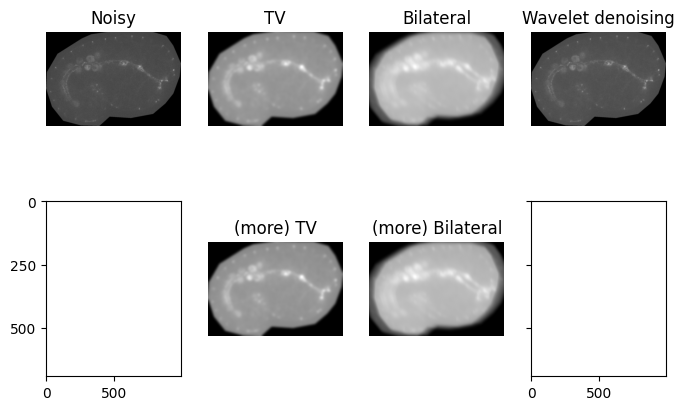

In [9]:
import matplotlib.pyplot as plt

from skimage.restoration import (
    denoise_tv_chambolle,
    denoise_bilateral,
    denoise_wavelet,
    estimate_sigma,
)
from skimage import data, img_as_float
from skimage.util import random_noise


# original = img_as_float(data.chelsea()[100:250, 50:300])

# sigma = 0.155
# noisy = random_noise(original, var=sigma**2)

noisy = image[30]
fig, ax = plt.subplots(nrows=2, ncols=4, figsize=(8, 5), sharex=True, sharey=True)


plt.gray()

# Estimate the average noise standard deviation across color channels.
sigma_est = estimate_sigma(noisy, average_sigmas=True)
# Due to clipping in random_noise, the estimate will be a bit smaller than the
# specified sigma.
print(f'Estimated Gaussian noise standard deviation = {sigma_est}')

ax[0, 0].imshow(noisy)
ax[0, 0].axis('off')
ax[0, 0].set_title('Noisy')
ax[0, 1].imshow(denoise_tv_chambolle(noisy, weight=0.1))
ax[0, 1].axis('off')
ax[0, 1].set_title('TV')
ax[0, 2].imshow(
    denoise_bilateral(noisy, sigma_color=0.05, sigma_spatial=15)
)
ax[0, 2].axis('off')
ax[0, 2].set_title('Bilateral')
ax[0, 3].imshow(denoise_wavelet(noisy, rescale_sigma=True))
ax[0, 3].axis('off')
ax[0, 3].set_title('Wavelet denoising')

ax[1, 1].imshow(denoise_tv_chambolle(noisy, weight=0.2))
ax[1, 1].axis('off')
ax[1, 1].set_title('(more) TV')
ax[1, 2].imshow(
    denoise_bilateral(noisy, sigma_color=0.1, sigma_spatial=15)
)
ax[1, 2].axis('off')
ax[1, 2].set_title('(more) Bilateral')
ax[1, 3].imshow(
    denoise_wavelet(noisy, convert2ycbcr=True, rescale_sigma=True)
)
ax[1, 3].axis('off')
ax[1, 3].set_title('Wavelet denoising\nin YCbCr colorspace')
ax[1, 0].imshow(original)
ax[1, 0].axis('off')
ax[1, 0].set_title('Original')

fig.tight_layout()

plt.show()

dtype: uint16, shape: (693, 989)
min: 0, max: 425, mean: 101.3617410563821
73.0 75.0


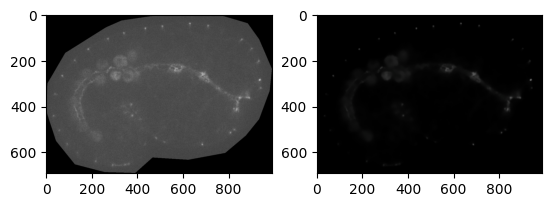

In [25]:
import numpy as np
import cv2 as cv
from matplotlib import pyplot as plt

img = cv.imread(
    os.path.join(input_directory, f"20251216_gapstrain_1_1_cropped.tif"),
    cv.IMREAD_ANYDEPTH,
)
img = image[30]
print(f"dtype: {img.dtype}, shape: {img.shape}")
print(f"min: {img.min()}, max: {img.max()}, mean: {img.mean()}")

# Normalize to 8-bit for processing
img_normalized = cv.normalize(img, None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)

# Convert to 3 channels if needed (fastNlMeansDenoisingColored requires 3 or 4 channels)
if len(img_normalized.shape) == 2:
    img_normalized = cv.cvtColor(img_normalized, cv.COLOR_GRAY2BGR)
elif img_normalized.shape[2] == 1:
    img_normalized = cv.cvtColor(img_normalized, cv.COLOR_GRAY2BGR)

# Now denoise
dst = cv.fastNlMeansDenoisingColored(img_normalized, None, 10, 10, 7, 21)

print(np.median(img_normalized), np.median(dst))
subtracted = cv.subtract(dst, 75)

plt.subplot(121), plt.imshow(cv.cvtColor(img_normalized, cv.COLOR_BGR2RGB), cmap="gray")
plt.subplot(122), plt.imshow(cv.cvtColor(dst, cv.COLOR_BGR2RGB), cmap="gray")
plt.subplot(122), plt.imshow(cv.cvtColor(subtracted, cv.COLOR_BGR2RGB), cmap="gray")
plt.show()